# Import Library

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Data Overview

## Load Dataset

In [35]:
df = pd.read_csv('https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/employee/employee_data.csv')
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

## Statistic

In [37]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [38]:
df.describe(include='object')

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,3,3,6,2,9,3,1,2
top,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1043,961,606,882,326,673,1470,1054


## Missing Value

In [39]:
df.isnull().sum()

,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


In [40]:
df['Attrition'].isnull().sum()

np.int64(412)

In [41]:
missing_percentage = df['Attrition'].isnull().mean() * 100
print(missing_percentage)

28.027210884353742


In [42]:
df.dtypes

,0
EmployeeId,int64
Age,int64
Attrition,float64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64


## Duplicated Value

In [43]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

0


# Exploratory Data Analysis

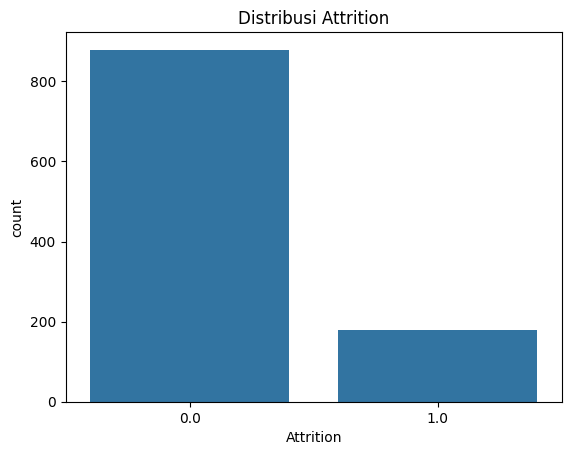

In [44]:
# @title Target Distribution
sns.countplot(x='Attrition', data=df)
plt.title('Distribusi Attrition')
plt.show()

In [45]:
# Cek Imbalance

df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
0.0,83.081285
1.0,16.918715


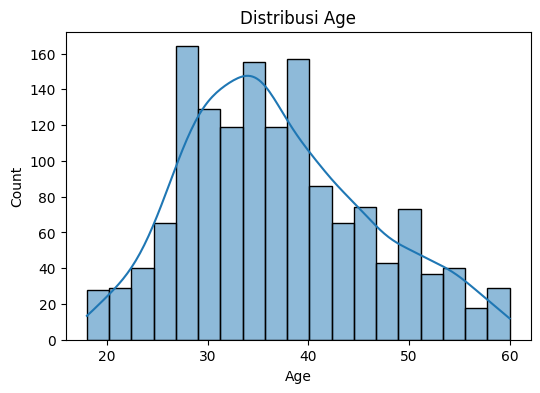

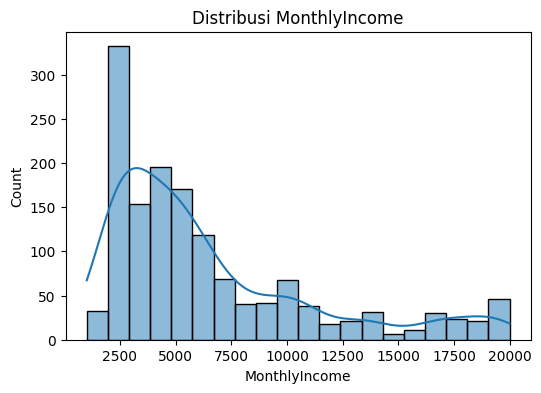

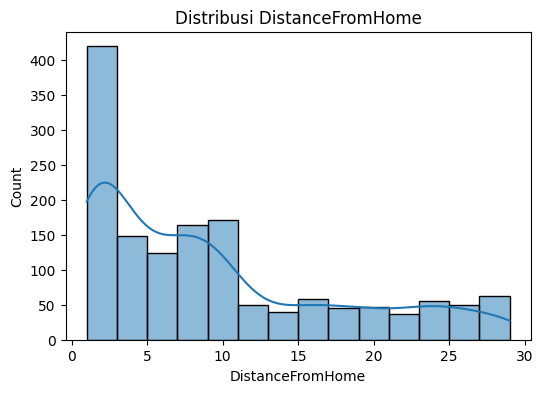

In [46]:
# $title Distribusi Numerikal

num_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()

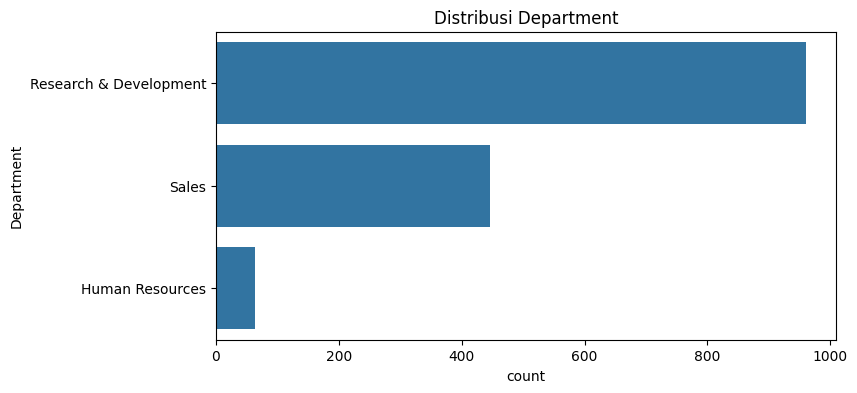

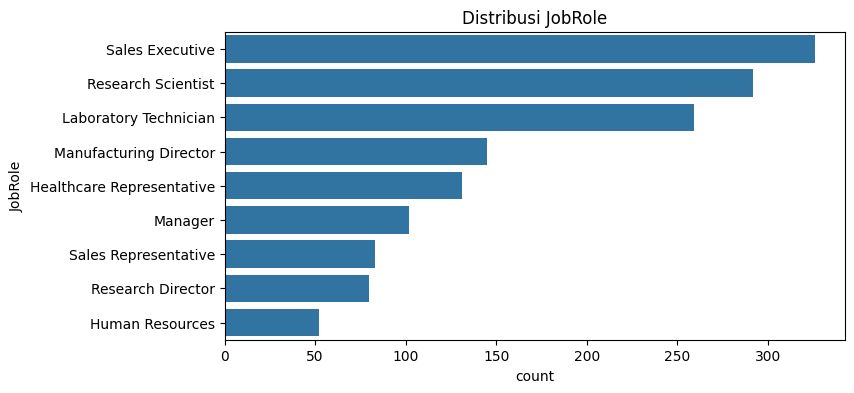

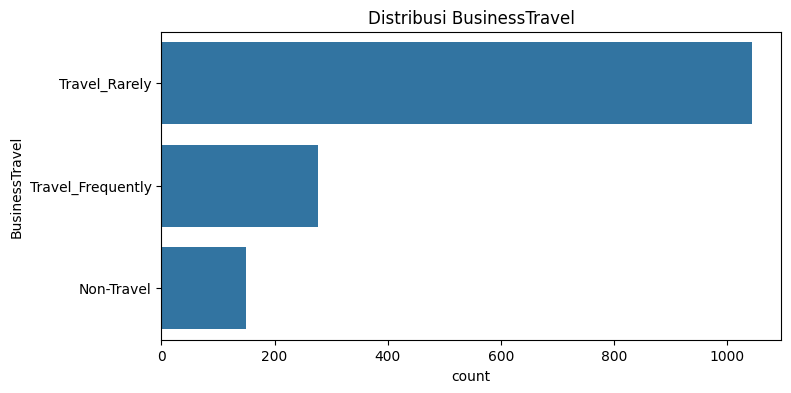

In [47]:
# $title Distribusi Kategorikal

cat_cols = ['Department', 'JobRole', 'BusinessTravel']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Distribusi {col}')
    plt.show()

## EDA Multivariate

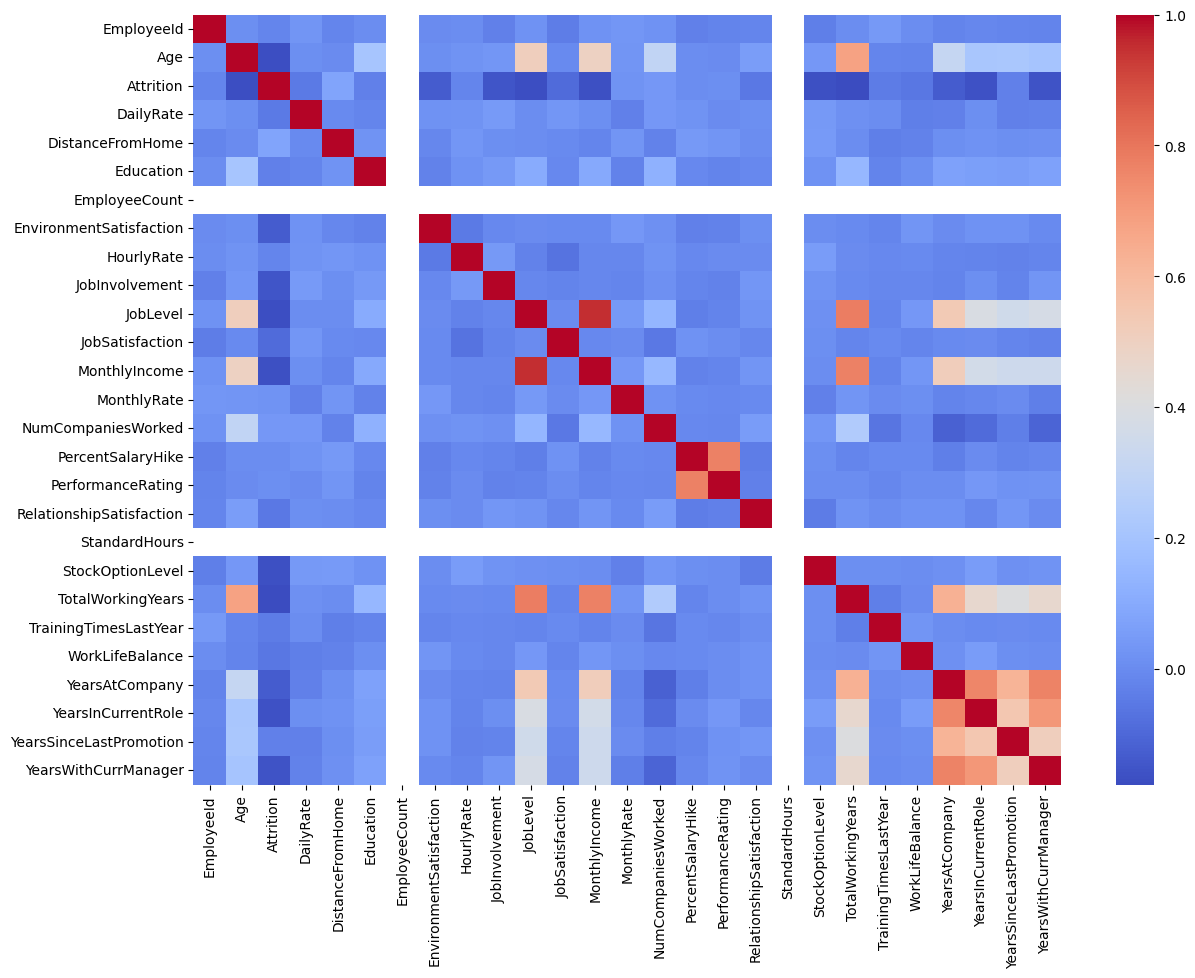

In [48]:
# @title Numerical Correlation

plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)
plt.show()

In [49]:
# # @title Attrition and Age

# plt.figure(figsize=(6,4))
# sns.boxplot(data=df, x='Attrition_Label', y='Age')
# plt.xticks([0,1], ['Stay', 'Exit'])
# plt.title('Perbandingan Umur vs Attrition')
# plt.show()

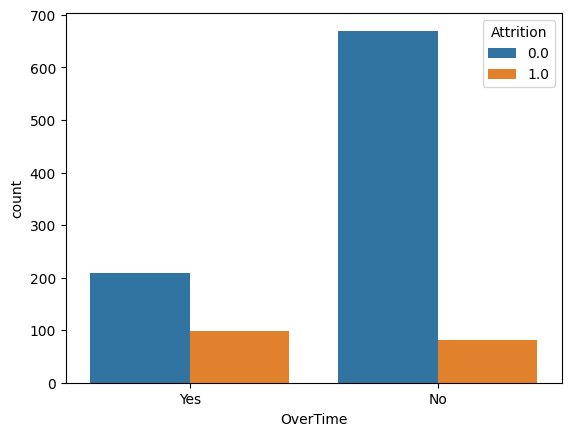

In [50]:
# @title Attrition and OverTime Work

sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.show()

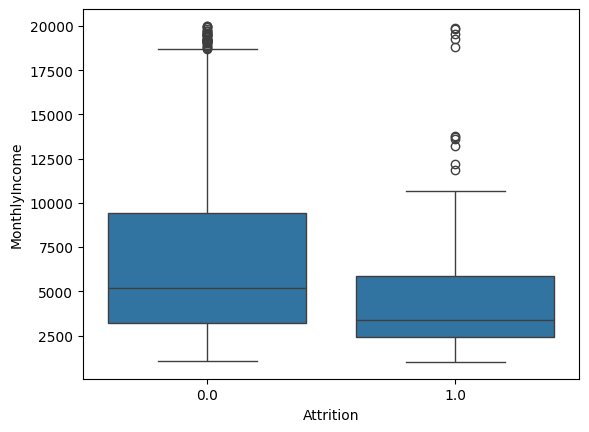

In [51]:
# @title Attrition and Monthly Income

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.show()

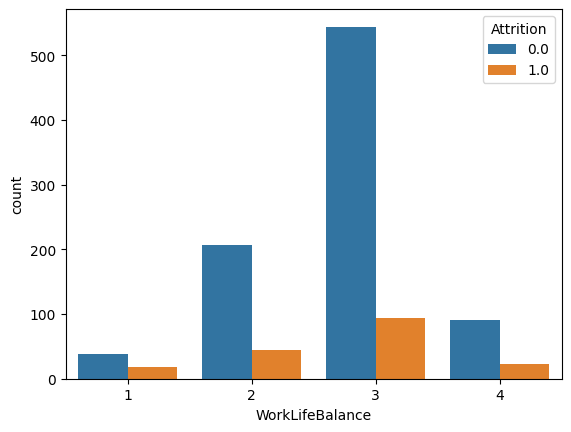

In [52]:
# @title Attrition and Work Life Balance

sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df
)
plt.show()

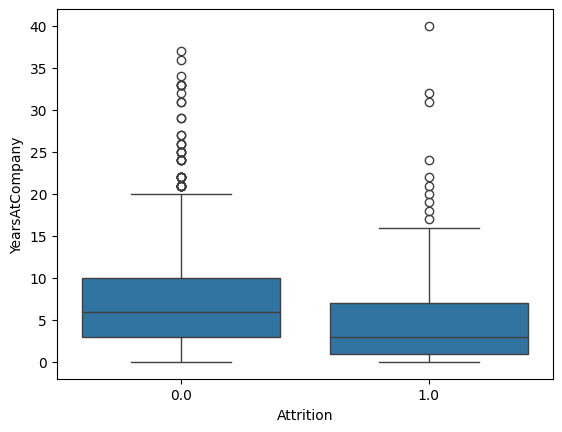

In [53]:
# @title Attrition and Years At Company

sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)
plt.show()

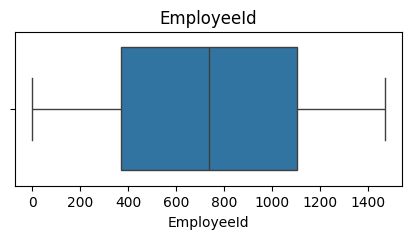

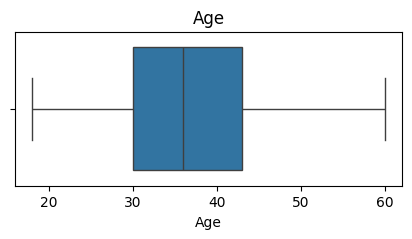

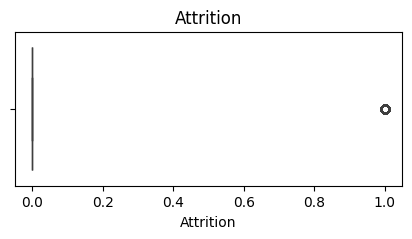

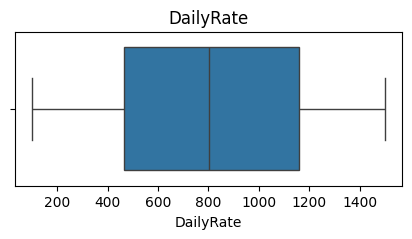

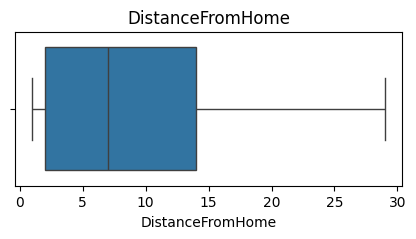

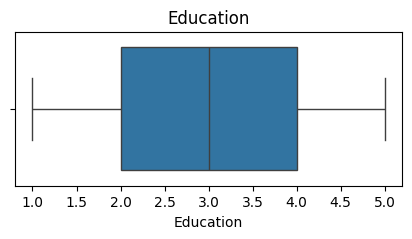

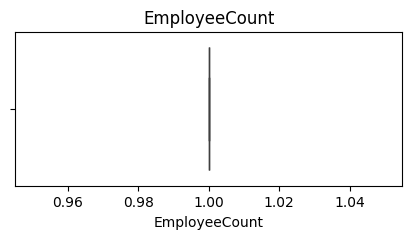

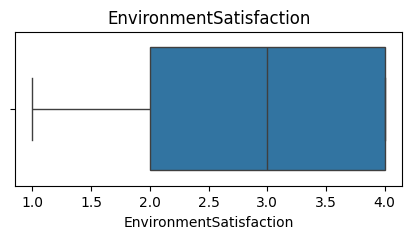

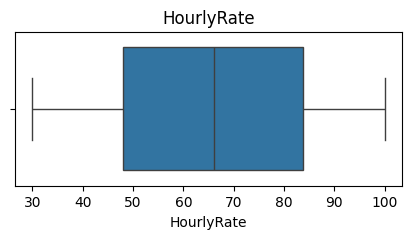

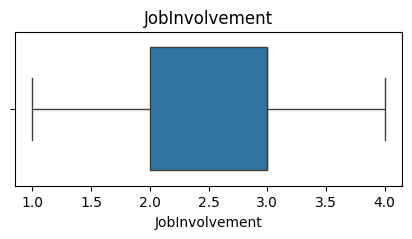

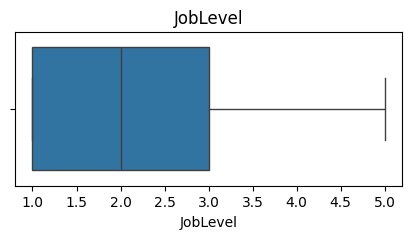

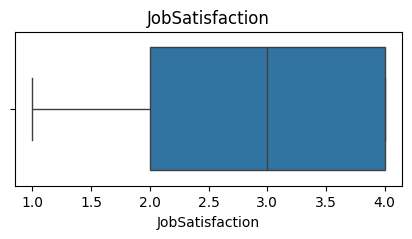

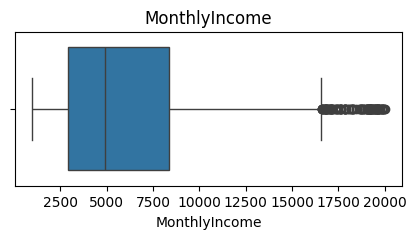

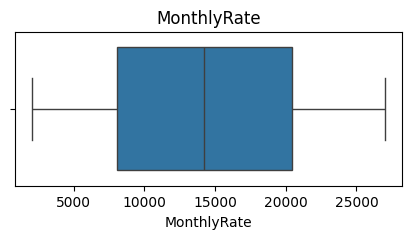

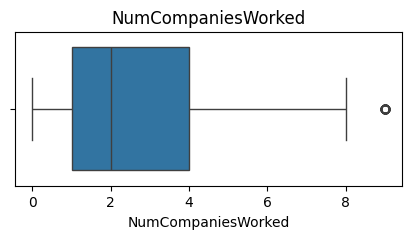

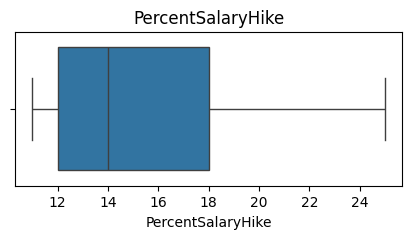

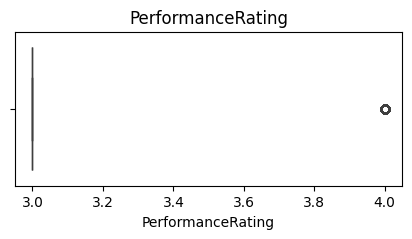

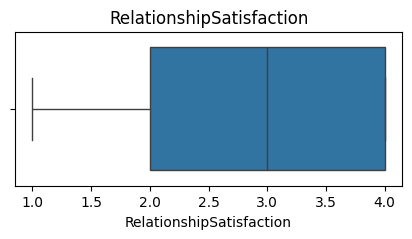

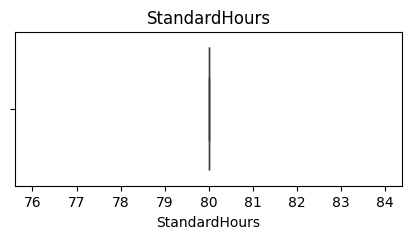

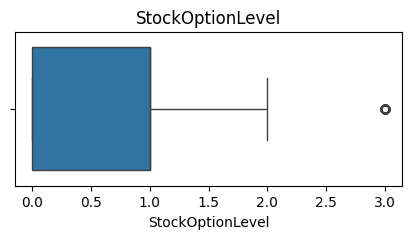

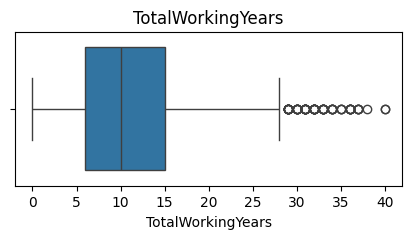

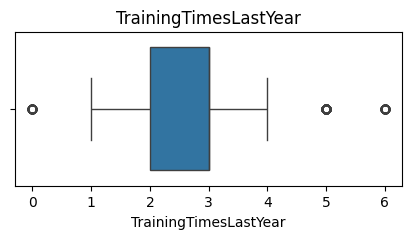

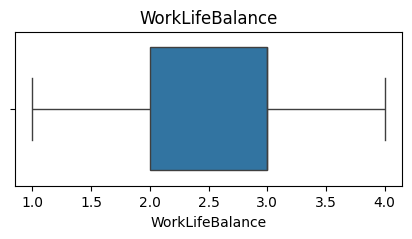

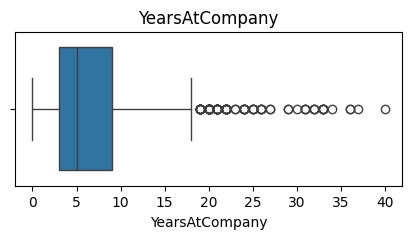

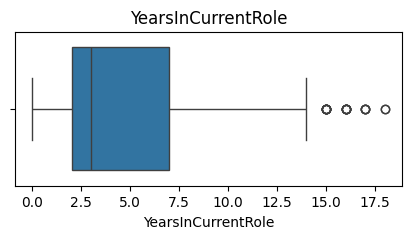

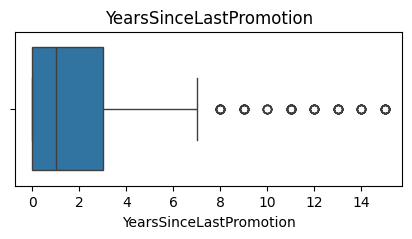

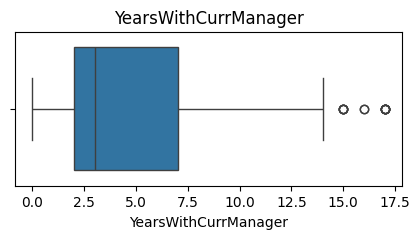

In [54]:
# @title Outlier

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Berdasarkan hasil EDA, ditemukan bahwa employee dengan overtime tinggi, work-life balance rendah, dan pendapatan bulanan rendah cenderung memiliki tingkat attrition lebih tinggi. Selain itu, dataset memiliki missing value sebesar ±28% pada kolom target attrition sehingga perlu dilakukan penanganan missing value sebelum proses modeling.

# Data Preparation

In [55]:
# Pisahkan data yang memiliki null value "Attrition", untuk nantinya dilakukan prediksi

df_train = df[df['Attrition'].notnull()]
df_missing = df[df['Attrition'].isnull()]

In [56]:
# Hapus kolom yang irrelevant dengan target

irr_cols = ['EmployeeId', 'Over18', 'StandardHours','EmployeeCount']

df_train = df_train.drop(columns=irr_cols)
df_missing = df_missing.drop(columns=irr_cols)

In [57]:
# Memisahkan fitur dan target

X = df_train.drop(['Attrition'], axis=1)
y = df_train['Attrition']

In [58]:
# Convert kolom kategorikal ke bentu numerik
categorical_cols = X.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))
    df_missing[col] = le.transform(df_missing[col].astype(str))

In [59]:
categorical_cols

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [60]:
X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,37,2,1141,1,11,2,3,1,0,61,...,3,1,0,15,2,1,1,0,0,0
2,51,2,1323,1,4,4,1,1,1,34,...,3,3,3,18,2,4,10,0,2,7
3,42,1,555,2,26,3,2,3,0,77,...,3,4,1,23,2,4,20,4,4,8
6,40,2,1124,2,1,2,3,2,1,57,...,4,3,3,6,2,2,4,3,0,2
7,55,2,725,1,2,3,3,4,1,78,...,3,4,1,24,2,3,5,2,1,4


In [61]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Data Splitting

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## SMOTE Over-Sampling

In [63]:
# Imbalance Data Handling dengan SMOTE
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

# Modelling

## Logistic Regression

In [64]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Random Forest

In [65]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# @title
# Coba Pakai GridSearchCV

In [99]:
# @title
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 200, 500],
#     'max_depth': [5, 10, 20],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
#     'class_weight': ['balanced']
# }

# grid = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grid,
#     cv=3,
#     scoring='f1',
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)

In [100]:
# @title
# print(grid.best_params_)

{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [101]:
# @title
# y_pred_best = best_rf.predict(X_test)

In [102]:
# @title
# print("Accuracy:",
#       accuracy_score(y_test, y_pred_best))

# print(classification_report(
#     y_test,
#     y_pred_best
# ))

Accuracy: 0.8537735849056604
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.92       176
         1.0       0.62      0.36      0.46        36

    accuracy                           0.85       212
   macro avg       0.75      0.66      0.69       212
weighted avg       0.84      0.85      0.84       212



In [86]:
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by='Importance',
    ascending=False
)

importance_rf.head(10)

,Feature,Importance
18,OverTime,0.135984
22,StockOptionLevel,0.074154
23,TotalWorkingYears,0.046828
13,JobSatisfaction,0.044784
14,MaritalStatus,0.043891
11,JobLevel,0.042670
0,Age,0.042027
10,JobInvolvement,0.040924
15,MonthlyIncome,0.034920
7,EnvironmentSatisfaction,0.031090


## XGBoost

In [66]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# Evaluation

## Logistic Regression

In [77]:
print(accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

0.7311320754716981
              precision    recall  f1-score   support

         0.0       0.93      0.73      0.82       176
         1.0       0.36      0.75      0.49        36

    accuracy                           0.73       212
   macro avg       0.65      0.74      0.65       212
weighted avg       0.84      0.73      0.76       212



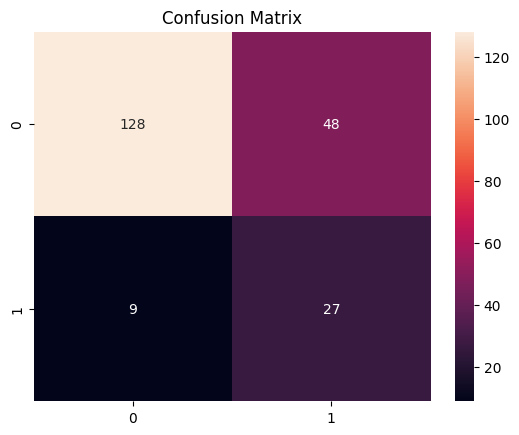

In [78]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.show()

## Random Forest

In [79]:
print(accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

0.8537735849056604
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.92       176
         1.0       0.62      0.36      0.46        36

    accuracy                           0.85       212
   macro avg       0.75      0.66      0.69       212
weighted avg       0.84      0.85      0.84       212



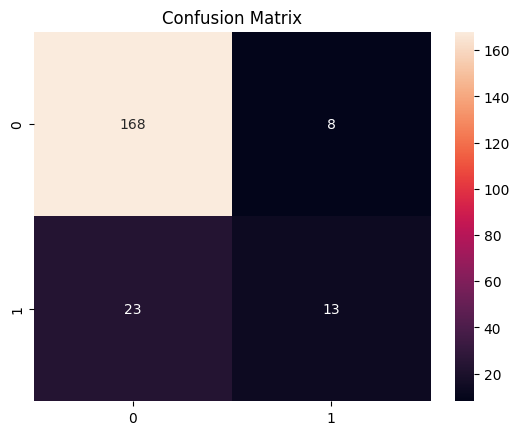

In [80]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.show()

In [81]:
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by='Importance',
    ascending=False
)

importance_rf.head(10)

,Feature,Importance
18,OverTime,0.135984
22,StockOptionLevel,0.074154
23,TotalWorkingYears,0.046828
13,JobSatisfaction,0.044784
14,MaritalStatus,0.043891
11,JobLevel,0.042670
0,Age,0.042027
10,JobInvolvement,0.040924
15,MonthlyIncome,0.034920
7,EnvironmentSatisfaction,0.031090


## XGBoost

In [82]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(classification_report(
    y_test,
    y_pred_xgb
))

Accuracy: 0.839622641509434
              precision    recall  f1-score   support

         0.0       0.88      0.94      0.91       176
         1.0       0.54      0.36      0.43        36

    accuracy                           0.84       212
   macro avg       0.71      0.65      0.67       212
weighted avg       0.82      0.84      0.83       212



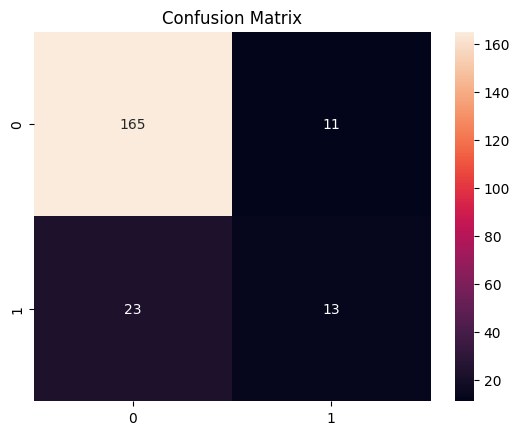

In [83]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.show()

# Prediction

In [88]:
X_missing = df_missing.drop('Attrition', axis=1)

X_missing_scaled = scaler.transform(X_missing)

pred_missing_rf = rf.predict(X_missing_scaled)

In [92]:
df['Attrition_pred'] = np.nan

In [93]:
df.loc[
    df['Attrition'].isnull(),
    'Attrition_pred'
] = pred_missing_rf

In [94]:
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_pred
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,80,1,7,2,3,6,2,1,2,0.0
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,80,0,15,2,1,1,0,0,0,NaN
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,80,3,18,2,4,10,0,2,7,NaN
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,80,1,23,2,4,20,4,4,8,NaN
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,80,3,20,2,3,5,3,0,2,0.0


In [95]:
df['Attrition_final'] = df['Attrition'].fillna(
    df['Attrition_pred']
)

In [96]:
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_pred,Attrition_final
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,1,7,2,3,6,2,1,2,0.0,0.0
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,0,15,2,1,1,0,0,0,NaN,1.0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,18,2,4,10,0,2,7,NaN,1.0
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,1,23,2,4,20,4,4,8,NaN,0.0
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,3,20,2,3,5,3,0,2,0.0,0.0


# Export

## Export Model

In [103]:
import pickle

In [104]:
with open('rf_attrition_model.pkl', 'wb') as file:
    pickle.dump(rf, file)

In [105]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [106]:
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(le, file)

## Export Data Result

In [107]:
df.to_csv(
    'Data Attrition HR Jaya Maju Dicoding.csv',
    index=False
)

In [108]:
df_missing.to_excel(
    'Data Attrition HR Jaya Maju Dicoding.xlsx',
    index=False
)